In [4]:
#   ☆ imports & such ☆
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
from matplotlib.patches import Patch
from matplotlib.animation import FuncAnimation, PillowWriter
import seaborn as sns
import matplotlib.dates as mdates
from scipy import stats
import rasterio as rio
import rioxarray as riox
from rasterio.enums import Resampling
from rasterio.crs import CRS
from rasterio.transform import from_bounds
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
import re

#for usgs data
#before analysis, run this pip install in terminal: pip install dataretrieval
import os
from dataretrieval import waterdata

#for earthaccess 
# before analysis, run this pip install in terminal: pip install earthaccess
import earthaccess

In [2]:
earthaccess.login()

results = earthaccess.search_data(
    concept_id="C3168830666-POCLOUD",
    temporal=("2021-08-20", "2021-09-10")
)

files = earthaccess.download(results, "/home/jovyan/creeproj/cygnss_ucb_cloud/")

QUEUEING TASKS | :   0%|          | 0/22 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/22 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/22 [00:00<?, ?it/s]

In [5]:
dataList = []
date_strs = []

for filepath in files:
    name = Path(filepath).name
    match = re.search(r'\d{4}-\d{2}-\d{2}', name)
    date_strs.append(match.group())

    data = xr.open_dataset(filepath)['watermask'].sel(
        lat=slice(29.377388, 30.505484),
        lon=slice(-90.697632, -89.456177)
    )
    dataList.append(data)

dates = pd.to_datetime(date_strs)

In [6]:
#Creating xarray cube and data frame for analysis
cygnsscube = xr.concat(dataList, dim='time')
cygnsscube['time'] = dates
cygnsscube = cygnsscube.assign_coords(time=dates)

cygnssdf=cygnsscube.mean(dim=['lat','lon']).to_dataframe()

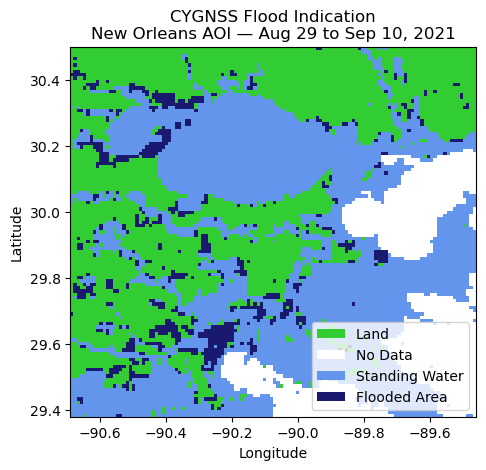

In [7]:
# Change in flooding indication between dates of Sentinel-1 passes
before = cygnsscube.sel(time='2021-08-29').values # Date of pre-ida S-1 pass
after  = cygnsscube.sel(time='2021-09-10').values # Date of post-ida S-1 pass

change_map = np.full(before.shape, np.nan) # Blank map with size/shape of cygnss product
change_map[(before == 0) & (after == 0)] = 0  # land before and after
change_map[(before == 1) & (after == 0)] = 0 # water > land (randoms/tidal)
change_map[(before == 1) & (after == 1)] = 1  # water before and after (permanent)
change_map[(before == 0) & (after == 1)] = 2  # land > water (flooded)

# Plot
cmap_change = mcolors.ListedColormap(['limegreen', 'cornflowerblue', 'midnightblue']) # land=green, standong H20=light blue, flood=dark blue
cmap_change.set_bad(color='white') # N/As=white

fig, ax = plt.subplots()
im = ax.imshow(
    change_map,
    cmap=cmap_change, vmin=0, vmax=2,
    origin='lower',
    extent=[float(cygnsscube.lon.min()), float(cygnsscube.lon.max()), 
            float(cygnsscube.lat.min()), float(cygnsscube.lat.max())]) # gives axes lon & lat values

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CYGNSS Flood Indication\nNew Orleans AOI — Aug 29 to Sep 10, 2021')

legend = [
    Patch(facecolor='limegreen', label='Land'),
    Patch(facecolor='white', label='No Data'),
    Patch(facecolor='cornflowerblue', label='Standing Water'),
    Patch(facecolor='midnightblue', label='Flooded Area')
]
ax.legend(handles=legend, loc='lower right')

# plt.savefig('watermask8.28.9.10.png', bbox_inches='tight')
plt.show()

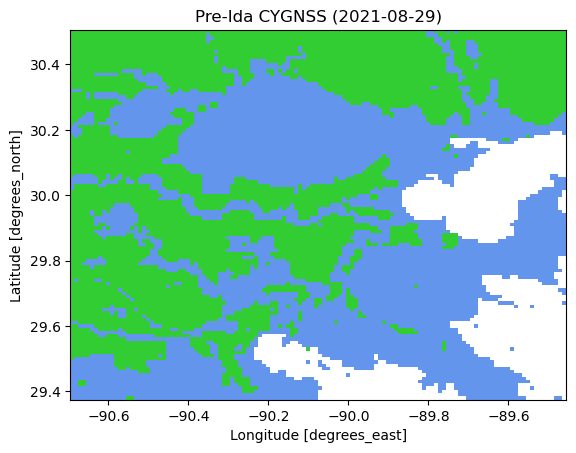

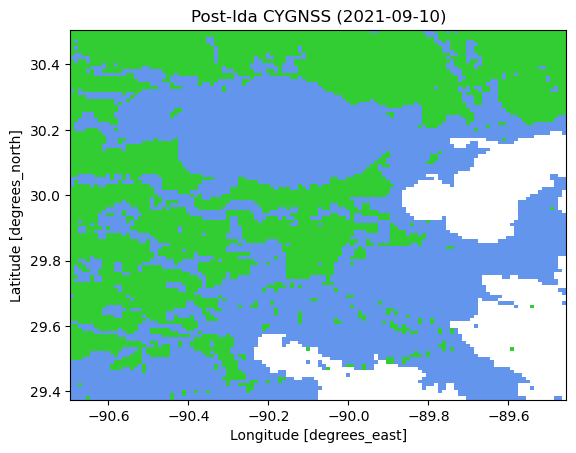

In [8]:
#Maps for presentation figures :)
bincmap= mcolors.ListedColormap(['limegreen', 'cornflowerblue'])
before_da = cygnsscube.sel(time='2021-08-29') 
before_da.plot(cmap=bincmap,add_colorbar=False)
plt.title('Pre-Ida CYGNSS (2021-08-29)')
plt.show()

after_da = cygnsscube.sel(time='2021-09-10') 
after_da.plot(cmap=bincmap,add_colorbar=False) 
plt.title('Post-Ida CYGNSS (2021-09-10)')
plt.show()

In [8]:
#Creating GEOTIFF for later S-1 comparison

lat = cygnsscube.lat.values
lon = cygnsscube.lon.values

transform = from_bounds(
    west=float(cygnsscube.lon.min()),
    south=float(cygnsscube.lat.min()),
    east=float(cygnsscube.lon.max()),
    north=float(cygnsscube.lat.max()),
    width=change_map.shape[1],
    height=change_map.shape[0]
)

with rio.open(
    '/home/jovyan/creeproj/cygnssreference.tif',
    'w',
    driver='GTiff',
    height=change_map.shape[0],
    width=change_map.shape[1],
    count=1,
    dtype='float32',
    crs='EPSG:4326',
    transform=transform,
    nodata=np.nan
) as dst:
    dst.write(change_map.astype('float32'), 1)

print('GeoTIFF saved.')

GeoTIFF saved.


In [ ]:
#Getting USGS meter gauge data into DF
os.environ["API_USGS_PAT"] = "xjhhTvUtNhm7RlSzHy8pXY5fKB7B3bZJ083RmF1n"

ground, metadata = waterdata.get_daily(
    monitoring_location_id= ['USGS-07381350','USGS-07380215','USGS-301324090382400','USGS-292952089453800'],
    parameter_code='00065',  
    time='2021-08-20/2021-09-10')

gauge = ground[['time', 'geometry', 'monitoring_location_id', 'value', 'unit_of_measure']]
gauge = gauge.dropna(subset=['value'], how='any')
gauge = gauge.sort_values('time')
gauge = gauge.reset_index(drop=True)

#What do we get?
gauge.head(4)
for loc, grp in gauge.groupby('monitoring_location_id'):
    print(loc, len(grp), grp['value'].min(), grp['value'].max())

In [ ]:
#Visualizing differences across USGS sites
gauge['time'] = pd.to_datetime(gauge['time']).dt.tz_localize(None)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=gauge, x='time', y='value', hue='monitoring_location_id',ax=ax, errorbar=None)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ida_date = pd.Timestamp('2021-08-29')
ax.axvline(ida_date, color='red', linestyle='-', linewidth=2)
ax.text(ida_date, ax.get_ylim()[1], 'Hurricane Ida',
        color='red', rotation=90, va='top', ha='right', fontsize=8)

lclegend = [
    Patch(facecolor='royalblue', label='Swamp'),
    Patch(facecolor='forestgreen', label='Marsh'),
    Patch(facecolor='darkorange', label='Residential'),
    Patch(facecolor='crimson', label= 'Agricultural'),
]
ax.legend(handles=lclegend, loc='lower right', fontsize=9)

ax.set_xlabel("Date")
ax.set_ylabel("Height (ft)")
ax.set_title('Water Gauge Height Change in New Orleans Sub-AOIs')
plt.tight_layout()
# plt.savefig('alllocs.png')
plt.show()


In [ ]:
#Representing change in flooded pixels within AOI as identified by CYGNSS RWAWC algorithm 
baseline = cygnssdf.loc['2021-08-29', 'watermask'] #takes pre-storm surface water as baseline
cygnssdf['diff'] = cygnssdf['watermask'] - baseline 
cygnssdf['pctchange'] = (cygnssdf['watermask'] - baseline) / baseline * 100 # difference in surface water extent from 8/28 for all days

#Joining cygnss & gauge data for plotting
daily_height = gauge.groupby('time')['value'].mean().rename('mean_height') # mean per day across all 4 locations
daily = daily_height.to_frame().join(cygnssdf['pctchange'], how='left').reset_index()

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(daily['time'], daily['mean_height'], color='tab:blue', label='Mean height (ft)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Mean height (ft)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(daily['time'], daily['pctchange'], color='tab:green', label='Watermask')
ax2.set_ylabel('Change in % of Flooded Pixels', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ida_date = pd.Timestamp('2021-08-29')
ax1.axvline(ida_date, color='red', linestyle='-', linewidth=1)
ax1.text(ida_date, ax1.get_ylim()[1], 'Hurricane Ida',
          color='red', rotation=90, va='top', ha='right', fontsize=8)


fig.suptitle('Mean Gauge Height and Inundated CYGNSS Pixels Over Time')
fig.autofmt_xdate()
plt.tight_layout()
# plt.savefig('gaugeheightvpixels.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# gauge height vs watermask
height_corr = stats.linregress(daily['mean_height'], daily['pctchange'])

print("\nGauge Height vs % Change in Flooding")
print(f"  r² = {height_corr.rvalue**2:.3f}")
print(f"  p-value = {height_corr.pvalue:.4f}")

In [ ]:
# plotted gauge height vs watermask
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(daily['mean_height'], daily['pctchange'], color='tab:blue')
ax.plot(daily['mean_height'], height_corr.intercept + height_corr.slope * daily['mean_height'], color='black')
ax.set_xlabel('Mean Gauge Height (ft)')
ax.set_ylabel('% Change in Flooding')
ax.set_title(f"Height vs % Change in Flooding (r²={height_corr.rvalue**2:.3f}), (p = {height_corr.pvalue:.4f})")

plt.tight_layout()
# plt.savefig('heightregression.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
with rio.open("/home/jovyan/creeproj/s1VV/S1VV.8.29.V3.tiff") as src:
    profile = src.profile
    raster_data = src.read()

profile.update(crs=CRS.from_epsg(4326))

with rio.open("output_with_crs829.tif", "w", **profile) as dst:
    dst.write(raster_data)

s1829 = riox.open_rasterio("/home/jovyan/creeproj/output_with_crs829.tif")

with rio.open("/home/jovyan/creeproj/s1VV/S1VV.9.10.V3.tiff") as src:
    profile = src.profile
    raster_data = src.read()

profile.update(crs=CRS.from_epsg(4326))

with rio.open("output_with_crs_910.tif", "w", **profile) as dst:
    dst.write(raster_data)

s1910 = riox.open_rasterio("/home/jovyan/creeproj/output_with_crs_910.tif")

#extract bands I want
s1829=s1829.sel(band=1)
s1910=s1910.sel(band=1)

#threshold= VV backscatter <-15 decibels (based on Chapman et al., 2022), 0.316 in linear 
binary829 = (s1829 < 0.316).where(~s1829.isnull()).astype(np.float32)
binary910 = (s1910 < 0.316).where(~s1910.isnull()).astype(np.float32)

s1change = xr.full_like(binary829, np.nan, dtype=np.float32) #shape of binary s-1 product

s1valid = binary829.notnull() & binary910.notnull() #collects usable values

s1change = s1change.where(~(s1valid & (binary829 == 0) & (binary910 == 0)), 0)
s1change = s1change.where(~(s1valid & (binary829 == 1) & (binary910 == 1)), 1)
s1change = s1change.where(~(s1valid & (binary829 == 0) & (binary910 == 1)), 2)

s1change.rio.to_raster("s1change.tif")

cygnssreference = riox.open_rasterio("/home/jovyan/creeproj/cygnssreference.tif").squeeze()

change_upscaled = s1change.rio.reproject_match(
    cygnssreference,
    resampling=Resampling.nearest) #upscales to match value of the s-1 pixel nearest to the center
                                    #of the larger 1km^2 sized group of s-1 pixels (not ideal- updates in progress)

change_upscaled.rio.to_raster("s1_upscaled.tif")

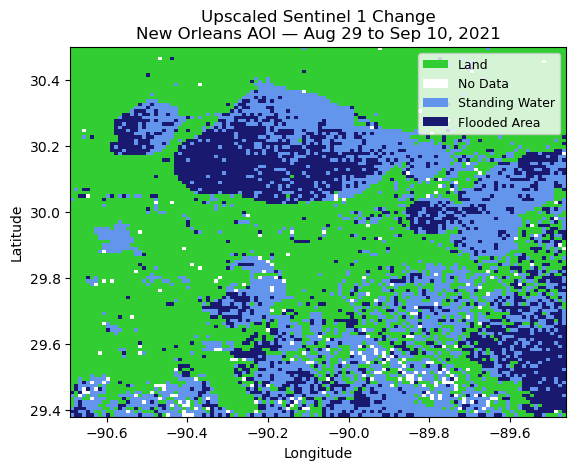

In [11]:
fig, ax = plt.subplots()

cmap = ListedColormap(["limegreen", "cornflowerblue", "midnightblue"])

change_upscaled.plot(cmap=cmap,
    vmin=-0.5,
    vmax=2.5,
    add_colorbar=False)

ax.legend(handles=legend, loc='upper right', fontsize=9)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Upscaled Sentinel 1 Change\nNew Orleans AOI — Aug 29 to Sep 10, 2021')

# plt.savefig('s1change829910.png')
plt.show()

In [11]:
# Assessing Agreement

#note: numeric categories change, where 0= no flooding/difference detected (land OR water), 1=flooding/difference detected.
#it is no longer 0= land, 1=water, 2= flood
s1_binary = xr.where(change_upscaled == 0, 0, 1)
cygnss_binary = xr.where(cygnssreference == 0, 0, 1)


cm = confusion_matrix(
    s1_binary.values.flatten(),
    cygnss_binary.values.flatten())

TN, FP, FN, TP = cm.ravel()

# print(f"TN = {TN}")
# print(f"FP = {FP}")
# print(f"FN = {FN}")
# print(f"TP = {TP}")
CSI = TP / (TP + FP + FN)
print("CSI:", CSI)
FAR = FP / (TP + FP)
print("False Alarm Rate:", FAR)
Accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", Accuracy)

CSI: 0.34225517677909395
False Alarm Rate: 0.5697396839831761
Accuracy: 0.48087353696831286


In [ ]:
comparison = xr.zeros_like(change_upscaled) #blank map with neccessary shape/size 

comparison = comparison.where(~((change_upscaled==0)&(cygnssreference==0)),0) #both say land
comparison = comparison.where(~((change_upscaled==1)&(cygnssreference==1)),1) # both say water
comparison = comparison.where(~((change_upscaled==1)&(cygnssreference==0)),2) # s-1 says water, cygnss says land
comparison = comparison.where(~((change_upscaled==0)&(cygnssreference==1)),3) #s-1 says land, cygnss says water

cmcmap = ListedColormap([
    "green",  
    "green",       # 0 & 1 = green (agreement)
    "midnightblue", # 2 = dark blue (disagreement)
    "crimson"       # 3 = crimson (disagreement)
])

fig, ax = plt.subplots()
comparison.plot(
    ax=ax,
    cmap=cmcmap,
    vmin=0,
    vmax=3,
    add_colorbar=False
)

cmlegend = [
    Patch(facecolor='green', label='Agreement (Land/Water)'),
    Patch(facecolor='midnightblue', label='Sentinel Water, CYGNSS Land'),
    Patch(facecolor='crimson', label='CYGNSS Water, Sentinel Land'),
]
ax.legend(handles=cmlegend, loc='lower right', fontsize=9)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title("Sentinel-1 vs CYGNSS Agreement")
# plt.savefig("cms1rwawc.png")
plt.show()